# 🧠 Engram: Full Interactive Pipeline Demo

**Authors:** Ashmita Dua (Research Lead) & Devesh Kriplani (Game Development Lead)  
**Affiliation:** Augmented Design Lab, UC Santa Cruz

---

This notebook runs the **complete Engram pipeline** — two NPCs with polar-opposite personalities process the same player interactions **side by side**.

### Full Loop
```
1. Define OCEAN vectors → Process backstory memories → Display
2. Player speaks → Threat assessment → Memory retrieval
3. Build structured prompt → LLM generates response
4. Prolog guardrail: tag response, check ±15% OCEAN alignment, feedback if needed
5. Player responds → Tag all three (response, player input, context)
6. Embedding match → OCEAN-weighted storage probability → Save memory
7. Next round — previous interaction now matters
8. All of this × 2 personalities, side by side
```

---
## 1. Setup

In [ ]:
!apt-get install -y swi-prolog > /dev/null 2>&1
!pip install pyswip google-generativeai numpy matplotlib seaborn pandas -q
print("✅ Dependencies installed.")

✅ Dependencies installed.


In [ ]:
import json, time, textwrap, copy
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple
from pyswip import Prolog
from IPython.display import display, HTML, Markdown

plt.rcParams['figure.facecolor'] = '#FAFAFA'
sns.set_style("whitegrid")
print("✅ Imports ready.")

✅ Imports ready.


In [ ]:
# ===== GEMINI API SETUP =====
# Add your Gemini API key via Colab Secrets (key name: GEMINI_API_KEY)
# Or paste directly below (less secure)

import google.generativeai as genai
from google.colab import userdata

try:
    api_key = userdata.get('GEMINI_API_KEY')
except:
    api_key = "----"  # <-- Paste your key here if not using Colab Secrets

if api_key:
    genai.configure(api_key=api_key)
    llm = genai.GenerativeModel('gemini-2.5-flash')
    LLM_AVAILABLE = True
    print("✅ Gemini API configured.")
else:
    LLM_AVAILABLE = False
    print("⚠️ No API key found. Set GEMINI_API_KEY in Colab Secrets.")
    print("   The notebook will not run without an LLM.")

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


✅ Gemini API configured.


---
## 2. Core Data Structures & Prolog Engine

In [ ]:
# ===== DATA STRUCTURES =====

@dataclass
class OCEANProfile:
    name: str
    openness: float
    conscientiousness: float
    extraversion: float
    agreeableness: float
    neuroticism: float

    def describe(self) -> str:
        """Human-readable personality description for prompts."""
        labels = {}
        for trait, val, name in [
            (self.openness, self.openness, "Openness"),
            (self.conscientiousness, self.conscientiousness, "Conscientiousness"),
            (self.extraversion, self.extraversion, "Extraversion"),
            (self.agreeableness, self.agreeableness, "Agreeableness"),
            (self.neuroticism, self.neuroticism, "Neuroticism")
        ]:
            if val >= 0.75: level = "Highly"
            elif val >= 0.4: level = "Mildly"
            else: level = "Low"
            labels[name] = level
        parts = [f"{lvl} {trait}" for trait, lvl in labels.items()]
        return ", ".join(parts)

    def vector(self) -> np.ndarray:
        return np.array([self.openness, self.conscientiousness,
                         self.extraversion, self.agreeableness, self.neuroticism])

    def __repr__(self):
        return (f"{self.name}: O={self.openness:.2f} C={self.conscientiousness:.2f} "
                f"E={self.extraversion:.2f} A={self.agreeableness:.2f} N={self.neuroticism:.2f}")


@dataclass
class EventTags:
    emotion_valence: float
    social_type: str
    threat_level: float
    goal_relevance: float
    novelty_level: float
    self_relevance: float

    def as_dict(self) -> Dict:
        social_map = {"solitude": 0.0, "conversation": 0.5,
                      "cooperation": 0.75, "conflict": 1.0}
        return {
            "emotion_valence": self.emotion_valence,
            "social_score": social_map.get(self.social_type, 0.5),
            "threat_level": self.threat_level,
            "goal_relevance": self.goal_relevance,
            "novelty_level": self.novelty_level,
            "self_relevance": self.self_relevance
        }

    def to_embedding(self) -> np.ndarray:
        d = self.as_dict()
        return np.array([d["emotion_valence"], d["social_score"], d["threat_level"],
                         d["goal_relevance"], d["novelty_level"], d["self_relevance"]])


@dataclass
class Memory:
    id: str
    description: str
    tags: EventTags
    source: str = "backstory"  # backstory | interaction
    strength: float = 0.5


@dataclass
class NPCState:
    """Full state for one NPC running the pipeline."""
    profile: OCEANProfile
    memories: List[Memory] = field(default_factory=list)
    conversation_history: List[Dict] = field(default_factory=list)
    memory_counter: int = 0

    def next_memory_id(self) -> str:
        self.memory_counter += 1
        return f"I{self.memory_counter}"


print("✅ Data structures defined.")

✅ Data structures defined.


In [ ]:
# ===== PROLOG ENGINE =====

prolog = Prolog()

prolog_rules = """
apply_openness_filter(Novelty, O, FN) :- FN is Novelty * (0.3 + 0.7 * O).
apply_social_weight(Social, E, WS) :- WS is Social * (0.2 + 0.8 * E).
apply_threat_sensitivity(Threat, N, TS) :-
    Raw is Threat * (0.3 + 1.2 * N), (Raw > 1.0 -> TS = 1.0 ; TS = Raw).
apply_goal_relevance(Goal, C, GW) :- GW is Goal * (0.2 + 0.8 * C).
apply_cooperative_bias(Social, Emotion, A, CW) :-
    (Emotion >= 0 -> CW is Social * (0.5 + 0.5 * A)
     ; CW is Social * (0.5 + 0.5 * (1.0 - A))).
compute_strength(FN, WS, TS, GW, CW, SR, S) :-
    Raw is (FN*0.15 + WS*0.15 + TS*0.25 + GW*0.2 + CW*0.1 + SR*0.15),
    (Raw > 1.0 -> S = 1.0 ; S = Raw).
process_memory(O, C, E, A, N, EV, SS, TL, GR, NL, SR, Strength) :-
    apply_openness_filter(NL, O, FN),
    apply_social_weight(SS, E, WS),
    apply_threat_sensitivity(TL, N, TS),
    apply_goal_relevance(GR, C, GW),
    apply_cooperative_bias(SS, EV, A, CW),
    compute_strength(FN, WS, TS, GW, CW, SR, Strength).
"""

with open('/tmp/engram.pl', 'w') as f:
    f.write(prolog_rules)
prolog.consult('/tmp/engram.pl')

def prolog_process(profile: OCEANProfile, tags: EventTags) -> Dict:
    p = profile
    t = tags.as_dict()
    q = list(prolog.query(
        f"process_memory({p.openness},{p.conscientiousness},{p.extraversion},"
        f"{p.agreeableness},{p.neuroticism},{t['emotion_valence']},{t['social_score']},"
        f"{t['threat_level']},{t['goal_relevance']},{t['novelty_level']},{t['self_relevance']},S)"
    ))
    strength = float(q[0]["S"]) if q else 0.0

    # Per-trait breakdowns
    bd = {}
    for name, query_str in [
        ("O_novelty", f"apply_openness_filter({t['novelty_level']},{p.openness},X)"),
        ("E_social", f"apply_social_weight({t['social_score']},{p.extraversion},X)"),
        ("N_threat", f"apply_threat_sensitivity({t['threat_level']},{p.neuroticism},X)"),
        ("C_goal", f"apply_goal_relevance({t['goal_relevance']},{p.conscientiousness},X)"),
        ("A_coop", f"apply_cooperative_bias({t['social_score']},{t['emotion_valence']},{p.agreeableness},X)"),
    ]:
        r = list(prolog.query(query_str))
        bd[name] = round(float(r[0]["X"]), 4) if r else 0.0

    return {"strength": round(strength, 4), "breakdown": bd}

print("✅ Prolog engine loaded.")

✅ Prolog engine loaded.


---
## 3. LLM Utility Functions

These call Gemini for: tagging events, threat assessment, generating NPC dialogue, and guardrail checking.

In [ ]:
def llm_call(prompt: str) -> str:
    """Raw LLM call with retry."""
    for attempt in range(3):
        try:
            resp = llm.generate_content(prompt)
            return resp.text.strip()
        except Exception as e:
            if attempt < 2:
                time.sleep(2)
            else:
                return f"[LLM Error: {e}]"


def llm_json(prompt: str) -> Dict:
    """LLM call that parses JSON response."""
    raw = llm_call(prompt)
    clean = raw.replace('```json', '').replace('```', '').strip()
    try:
        return json.loads(clean)
    except:
        return {"error": "JSON parse failed", "raw": raw}


# ─────────────────────────────────────────────
# 1. TAG AN EVENT / DIALOGUE
# ─────────────────────────────────────────────
def llm_tag_event(text: str, context: str = "") -> EventTags:
    """Use LLM to generate semantic tags for any text."""
    prompt = f"""You are a semantic tagger for an NPC memory system.

Given the following text (and optional context), output ONLY a JSON object:
{{
  "emotion_valence": <float -1.0 to 1.0>,
  "social_type": <"solitude"|"conversation"|"cooperation"|"conflict">,
  "threat_level": <float 0.0 to 1.0>,
  "goal_relevance": <float 0.0 to 1.0>,
  "novelty_level": <float 0.0 to 1.0>,
  "self_relevance": <float 0.0 to 1.0>
}}

Context: {context}
Text: {text}

Return ONLY valid JSON."""
    data = llm_json(prompt)
    if "error" in data:
        return EventTags(0, "conversation", 0, 0, 0.5, 0.5)
    return EventTags(**data)


# ─────────────────────────────────────────────
# 2. THREAT ASSESSMENT + MEMORY RETRIEVAL PATH
# ─────────────────────────────────────────────
def llm_threat_assessment(player_input: str, npc: NPCState) -> Dict:
    """Assess: is this a threat? Has this happened before? Decide retrieval path."""
    memory_summaries = "\n".join(
        [f"- [{m.id}] {m.description[:80]}" for m in npc.memories[-10:]]
    )
    prompt = f"""You are assessing an NPC's reaction to player input.

NPC personality: {npc.profile.describe()}

NPC's known memories:
{memory_summaries}

Player says: "{player_input}"

Assess and return ONLY this JSON:
{{
  "is_threat": <true|false>,
  "threat_reasoning": "<one sentence>",
  "happened_before": <true|false>,
  "similar_memory_id": "<memory ID or null>",
  "response_mode": "<dialogue|action|dialogue+action>",
  "retrieval_path": "<fight_flight|retrieve_memory|retrieve_relevant_schema>"
}}

Decision tree:
- is_threat=true + happened_before=false → fight_flight
- is_threat=true + happened_before=true → retrieve_memory
- is_threat=false + happened_before=true → retrieve_memory
- is_threat=false + happened_before=false → retrieve_relevant_schema

Return ONLY valid JSON."""
    return llm_json(prompt)


# ─────────────────────────────────────────────
# 3. GENERATE NPC RESPONSE (STRUCTURED PROMPT)
# ─────────────────────────────────────────────
def generate_npc_response(player_input: str, npc: NPCState,
                          assessment: Dict, retrieved_memories: List[Memory]) -> str:
    """Build the full structured prompt and generate NPC response."""
    mem_text = "\n".join(
        [f"- {m.description[:100]}" for m in retrieved_memories]
    ) if retrieved_memories else "No directly relevant memories."

    conv_history = ""
    for turn in npc.conversation_history[-4:]:
        conv_history += f"Player: {turn.get('player', '')}\nNPC: {turn.get('npc', '')}\n"

    prompt = f"""You are an NPC named Rico in a port-town game set in 1650s England.

═══ TASK ═══
Respond in: {assessment.get('response_mode', 'dialogue')}
Retrieval path: {assessment.get('retrieval_path', 'retrieve_relevant_schema')}
Threat detected: {assessment.get('is_threat', False)}

═══ CURRENT CONTEXT ═══
Player says: "{player_input}"

═══ CONVERSATION HISTORY ═══
{conv_history if conv_history else 'This is the start of the conversation.'}

═══ CHARACTER BACKGROUND ═══
Rico is 37, Portuguese family in England. Dock worker and smuggler.
Father abandoned the family. Brother Tomas died of TB. Brother Miguel died at war.
Has a long-distance girlfriend Sofia in Lisbon.

═══ RELEVANT MEMORIES ═══
{mem_text}

═══ PERSONALITY ═══
Before you write or take action, know that you have a personality of:
{npc.profile.describe()}

O={npc.profile.openness:.2f} → {'Embrace new ideas, update beliefs' if npc.profile.openness > 0.5 else 'Resist change, stick to what you know'}
C={npc.profile.conscientiousness:.2f} → {'Goal-focused, structured thinking' if npc.profile.conscientiousness > 0.5 else 'Spontaneous, go with the flow'}
E={npc.profile.extraversion:.2f} → {'Social, talkative, warm' if npc.profile.extraversion > 0.5 else 'Reserved, brief, guarded'}
A={npc.profile.agreeableness:.2f} → {'Cooperative, trusting, helpful' if npc.profile.agreeableness > 0.5 else 'Suspicious, competitive, self-serving'}
N={npc.profile.neuroticism:.2f} → {'Anxious, threat-aware, emotional' if npc.profile.neuroticism > 0.5 else 'Calm, stable, unbothered'}

═══ RULES ═══
- Stay in character. 2-4 sentences max.
- If response_mode includes 'action', describe a physical action in *asterisks*.
- Your response should CLEARLY reflect your personality traits.
- Do NOT break character or mention game mechanics.

Respond as Rico:"""
    return llm_call(prompt)


# ─────────────────────────────────────────────
# 4. PROLOG GUARDRAIL: TAG + CHECK ±15%
# ─────────────────────────────────────────────
def guardrail_check(npc_response: str, npc: NPCState,
                    retrieved_memories: List[Memory]) -> Dict:
    """
    Tag the NPC response, compare to what OCEAN profile expects
    based on similar memories. If >15% off, provide feedback.
    """
    # Tag the response
    response_tags = llm_tag_event(npc_response, "NPC dialogue response")
    response_processed = prolog_process(npc.profile, response_tags)

    # Get expected tag profile from similar memories
    if retrieved_memories:
        avg_tags = np.mean(
            [m.tags.to_embedding() for m in retrieved_memories], axis=0
        )
    else:
        avg_tags = np.array([0, 0.5, 0.3, 0.3, 0.5, 0.5])

    response_vec = response_tags.to_embedding()
    tag_names = ["emotion", "social", "threat", "goal", "novelty", "self_relevance"]

    deviations = {}
    feedback_needed = False
    feedback_parts = []

    for i, name in enumerate(tag_names):
        diff = response_vec[i] - avg_tags[i]
        deviations[name] = {"response": round(float(response_vec[i]), 3),
                            "expected": round(float(avg_tags[i]), 3),
                            "diff": round(float(diff), 3)}
        if abs(diff) > 0.15:
            feedback_needed = True
            direction = "more" if diff < 0 else "less"
            feedback_parts.append(
                f"Be {direction} {name} by {abs(diff)*100:.0f}%"
            )

    return {
        "response_tags": response_tags,
        "response_processed": response_processed,
        "deviations": deviations,
        "feedback_needed": feedback_needed,
        "feedback": "; ".join(feedback_parts) if feedback_parts else "✅ Within bounds",
        "passed": not feedback_needed
    }


print("✅ LLM utility functions defined.")

✅ LLM utility functions defined.


---
## 4. Embedding & Memory Retrieval

In [ ]:
def cosine_sim(a: np.ndarray, b: np.ndarray) -> float:
    norm = np.linalg.norm(a) * np.linalg.norm(b)
    return float(np.dot(a, b) / norm) if norm > 0 else 0.0


def retrieve_similar_memories(query_tags: EventTags, npc: NPCState,
                              top_k: int = 3) -> List[Tuple[Memory, float]]:
    """Find most similar memories by embedding cosine similarity."""
    query_vec = query_tags.to_embedding()
    scored = []
    for m in npc.memories:
        sim = cosine_sim(query_vec, m.tags.to_embedding())
        scored.append((m, sim))
    scored.sort(key=lambda x: x[1], reverse=True)
    return scored[:top_k]


def ocean_storage_probability(profile: OCEANProfile, tags: EventTags,
                               embedding_match: float) -> Dict:
    """
    OCEAN-weighted probability of storing a new memory.
    Each trait has a domain it governs — if the memory is tagged in that
    domain, the trait score * embedding match = storage probability.
    """
    t = tags.as_dict()
    results = {}

    # O: novelty → likely to update beliefs
    o_signal = t["novelty_level"]
    results["O_update"] = {
        "score": round(profile.openness * o_signal * embedding_match, 3),
        "action": "Likely to update/revise existing memory",
        "active": o_signal > 0.4
    }

    # C: goal relevance → detailed, goal-oriented storage
    c_signal = t["goal_relevance"]
    results["C_detail"] = {
        "score": round(profile.conscientiousness * c_signal * embedding_match, 3),
        "action": "Likely to store as detailed, goal-oriented memory",
        "active": c_signal > 0.4
    }

    # E: social → reinforce social bonds
    e_signal = t["social_score"]
    results["E_social"] = {
        "score": round(profile.extraversion * e_signal * embedding_match, 3),
        "action": "Likely to reinforce social memory",
        "active": e_signal > 0.4
    }

    # A: positive emotion + social → encourage helpfulness memory
    a_signal = max(0, t["emotion_valence"]) * t["social_score"]
    results["A_helpful"] = {
        "score": round(profile.agreeableness * a_signal * embedding_match, 3),
        "action": "Likely to encourage helpfulness memory",
        "active": a_signal > 0.2
    }

    # N: negative emotion / threat → reinforce bad memories
    n_signal = max(0, -t["emotion_valence"]) * t["threat_level"]
    results["N_negative"] = {
        "score": round(profile.neuroticism * max(n_signal, t["threat_level"]) * embedding_match, 3),
        "action": "Likely to reinforce negative/threat memory",
        "active": t["threat_level"] > 0.3 or t["emotion_valence"] < -0.3
    }

    # Overall storage probability
    active_scores = [v["score"] for v in results.values() if v["active"]]
    overall = max(active_scores) if active_scores else 0.1
    results["overall_probability"] = round(min(overall * 1.5, 1.0), 3)

    return results


print("✅ Embedding & storage functions defined.")

✅ Embedding & storage functions defined.


---
## 5. Display Helpers (Side-by-Side HTML)

In [ ]:
def side_by_side(left_title, left_html, right_title, right_html):
    """Display two panels side by side."""
    display(HTML(f"""
    <div style="display:flex; gap:16px; margin:10px 0;">
      <div style="flex:1; border:2px solid #DC2626; border-radius:8px; padding:12px; background:#FFF5F5;">
        <h4 style="color:#DC2626; margin:0 0 8px 0;">🔴 {left_title}</h4>
        {left_html}
      </div>
      <div style="flex:1; border:2px solid #0D9488; border-radius:8px; padding:12px; background:#F0FDFA;">
        <h4 style="color:#0D9488; margin:0 0 8px 0;">🟢 {right_title}</h4>
        {right_html}
      </div>
    </div>
    """))


def format_tags_html(tags: EventTags) -> str:
    t = tags.as_dict()
    rows = ""
    for k, v in t.items():
        bar_w = abs(float(v)) * 100
        color = "#DC2626" if float(v) < 0 else "#0D9488"
        rows += f"<tr><td style='font-size:11px;'>{k}</td><td style='font-size:11px;'>{v:+.2f}</td>"
        rows += f"<td><div style='background:{color};width:{bar_w}%;height:10px;border-radius:3px;'></div></td></tr>"
    return f"<table style='width:100%;'>{rows}</table>"


def format_assessment_html(a: Dict) -> str:
    threat = "🚨 YES" if a.get('is_threat') else "✅ No"
    before = "🔁 Yes" if a.get('happened_before') else "🆕 No"
    path = a.get('retrieval_path', '?')
    mode = a.get('response_mode', '?')
    return f"""
    <div style='font-size:12px;'>
    <b>Threat?</b> {threat}<br>
    <b>Happened before?</b> {before}<br>
    <b>Path:</b> <code>{path}</code><br>
    <b>Mode:</b> <code>{mode}</code><br>
    <i style='color:#666;'>{a.get('threat_reasoning', '')}</i>
    </div>"""


def format_guardrail_html(g: Dict) -> str:
    status = "✅ PASSED" if g['passed'] else "⚠️ FEEDBACK NEEDED"
    rows = ""
    for k, v in g['deviations'].items():
        diff = v['diff']
        color = "#DC2626" if abs(diff) > 0.15 else "#666"
        flag = " ⚠️" if abs(diff) > 0.15 else ""
        rows += f"<tr><td style='font-size:11px;'>{k}</td>"
        rows += f"<td style='font-size:11px;'>{v['response']:.2f}</td>"
        rows += f"<td style='font-size:11px;'>{v['expected']:.2f}</td>"
        rows += f"<td style='font-size:11px;color:{color};'>{diff:+.2f}{flag}</td></tr>"
    return f"""
    <b>{status}</b><br>
    <table style='width:100%;margin-top:4px;'>
    <tr><th style='font-size:10px;text-align:left;'>Tag</th>
    <th style='font-size:10px;'>Response</th>
    <th style='font-size:10px;'>Expected</th>
    <th style='font-size:10px;'>Diff</th></tr>
    {rows}</table>
    <div style='font-size:11px;margin-top:4px;'><b>Feedback:</b> {g['feedback']}</div>"""


def format_storage_html(storage: Dict) -> str:
    rows = ""
    for k, v in storage.items():
        if k == "overall_probability":
            continue
        active = "🟢" if v['active'] else "⚫"
        rows += f"<tr><td style='font-size:11px;'>{active} {k}</td>"
        rows += f"<td style='font-size:11px;'>{v['score']:.3f}</td>"
        rows += f"<td style='font-size:11px;'>{v['action']}</td></tr>"
    prob = storage['overall_probability']
    color = "#0D9488" if prob > 0.5 else "#F59E0B" if prob > 0.25 else "#DC2626"
    return f"""
    <table style='width:100%;'>{rows}</table>
    <div style='margin-top:6px;font-size:14px;'>
    <b>Storage Probability:</b> <span style='color:{color};font-size:18px;font-weight:bold;'>{prob:.1%}</span>
    </div>"""


print("✅ Display helpers defined.")

✅ Display helpers defined.


---
## 6. Define Two Polar-Opposite NPCs + Load Backstory

In [ ]:
# ===== TWO POLAR OPPOSITE RICO VARIANTS =====

# Rico A: The Paranoid Guard — closed, rigid, solitary, suspicious, anxious
rico_a = NPCState(
    profile=OCEANProfile(
        name="Rico-A (Paranoid)",
        openness=0.1, conscientiousness=0.9,
        extraversion=0.15, agreeableness=0.1, neuroticism=0.95
    )
)

# Rico B: The Charming Rogue — open, spontaneous, social, trusting, calm
rico_b = NPCState(
    profile=OCEANProfile(
        name="Rico-B (Charming)",
        openness=0.9, conscientiousness=0.15,
        extraversion=0.9, agreeableness=0.85, neuroticism=0.1
    )
)

# ===== LOAD BACKSTORY MEMORIES =====
backstory_data = [
    ("M1", "Father abandoned the family when Rico was young",
     EventTags(-0.85, "conflict", 0.7, 0.3, 0.8, 1.0)),
    ("M2", "Worked the docks as a child, learned survival and trade",
     EventTags(-0.2, "cooperation", 0.3, 0.7, 0.2, 0.7)),
    ("M3", "Brother Tomas died of tuberculosis — poverty killed him",
     EventTags(-0.95, "solitude", 0.8, 0.6, 0.7, 0.95)),
    ("M4", "Brother Miguel died at war — loyalty didn't save him",
     EventTags(-0.9, "conflict", 0.85, 0.5, 0.6, 0.9)),
    ("M5", "Met Sofia at the docks — she sees the real Tyrone",
     EventTags(0.85, "conversation", 0.0, 0.4, 0.75, 0.85)),
    ("M6", "First time smuggling goods — rules are for the powerful",
     EventTags(0.3, "cooperation", 0.5, 0.85, 0.7, 0.8)),
]

for npc in [rico_a, rico_b]:
    for mid, desc, tags in backstory_data:
        result = prolog_process(npc.profile, tags)
        npc.memories.append(Memory(id=mid, description=desc,
                                   tags=tags, source="backstory",
                                   strength=result["strength"]))
    npc.memory_counter = len(backstory_data)

print("✅ Two Rico variants loaded with backstory.\n")

# Display side by side
def memories_html(npc: NPCState) -> str:
    rows = ""
    for m in npc.memories:
        bar = int(m.strength * 20) * '█' + (20 - int(m.strength * 20)) * '░'
        rows += f"<tr><td style='font-size:11px;'><b>{m.id}</b></td>"
        rows += f"<td style='font-size:11px;'>{m.description[:50]}</td>"
        rows += f"<td style='font-size:11px;font-family:monospace;'>{bar} {m.strength:.3f}</td></tr>"
    return f"<div style='font-size:12px;'><b>{npc.profile.describe()}</b></div><table style='width:100%;margin-top:6px;'>{rows}</table>"

display(HTML("<h3>📊 Backstory Memory Strength (Prolog-processed)</h3>"))
side_by_side(rico_a.profile.name, memories_html(rico_a),
             rico_b.profile.name, memories_html(rico_b))

✅ Two Rico variants loaded with backstory.



M1,Father abandoned the family when Rico was young,████████████░░░░░░░░ 0.643
M2,"Worked the docks as a child, learned survival and",█████████░░░░░░░░░░░ 0.460
M3,Brother Tomas died of tuberculosis — poverty kille,██████████░░░░░░░░░░ 0.542
M4,Brother Miguel died at war — loyalty didn't save h,█████████████░░░░░░░ 0.653
M5,Met Sofia at the docks — she sees the real Tyrone,█████░░░░░░░░░░░░░░░ 0.294
M6,First time smuggling goods — rules are for the pow,███████████░░░░░░░░░ 0.573
M1,Father abandoned the family when Rico was young,██████████░░░░░░░░░░ 0.550
M2,"Worked the docks as a child, learned survival and",███████░░░░░░░░░░░░░ 0.356
M3,Brother Tomas died of tuberculosis — poverty kille,███████░░░░░░░░░░░░░ 0.362
M4,Brother Miguel died at war — loyalty didn't save h,██████████░░░░░░░░░░ 0.535
M5,Met Sofia at the docks — she sees the real Tyrone,███████░░░░░░░░░░░░░ 0.373


---
## 7. 🎮 The Full Pipeline — One Interaction Loop

This function runs the **complete Engram loop** for one player input, side by side.

In [ ]:
def run_interaction(player_input: str, npc_a: NPCState, npc_b: NPCState,
                    round_num: int = 1):
    """
    Run the FULL Engram pipeline for one player input, side by side.
    Returns both NPC responses for chaining.
    """
    display(HTML(f"""
    <div style='background:#1E293B;color:white;padding:12px;border-radius:8px;
                margin:20px 0 10px 0;font-size:16px;'>
    <b>🎮 ROUND {round_num}</b> — Player says: <i>"{player_input}"</i>
    </div>"""))

    responses = {}

    for label, npc, color in [("A", npc_a, "#DC2626"), ("B", npc_b, "#0D9488")]:
        pass  # We'll process both then display

    # ── STEP 1: Threat Assessment ──
    display(HTML("<h4>STEP 1: Threat Assessment & Retrieval Path</h4>"))
    assess_a = llm_threat_assessment(player_input, npc_a)
    assess_b = llm_threat_assessment(player_input, npc_b)
    side_by_side(npc_a.profile.name, format_assessment_html(assess_a),
                 npc_b.profile.name, format_assessment_html(assess_b))

    # ── STEP 2: Memory Retrieval (Embedding Match) ──
    display(HTML("<h4>STEP 2: Memory Retrieval (Embedding Similarity)</h4>"))
    input_tags = llm_tag_event(player_input, "Player speaking to NPC Rico at the docks")
    display(HTML(f"<div style='font-size:12px;background:#F8FAFC;padding:8px;border-radius:6px;'>"
                 f"<b>Player Input Tags:</b> {format_tags_html(input_tags)}</div>"))

    retrieved_a = retrieve_similar_memories(input_tags, npc_a, top_k=3)
    retrieved_b = retrieve_similar_memories(input_tags, npc_b, top_k=3)

    def retrieval_html(retrieved):
        rows = ""
        for m, sim in retrieved:
            rows += f"<tr><td style='font-size:11px;'><b>{m.id}</b></td>"
            rows += f"<td style='font-size:11px;'>{m.description[:55]}</td>"
            rows += f"<td style='font-size:11px;'>{sim:.3f}</td></tr>"
        return f"<table style='width:100%;'><tr><th>ID</th><th>Memory</th><th>Similarity</th></tr>{rows}</table>"

    side_by_side(npc_a.profile.name, retrieval_html(retrieved_a),
                 npc_b.profile.name, retrieval_html(retrieved_b))

    # ── STEP 3: Generate NPC Response ──
    display(HTML("<h4>STEP 3: LLM Response Generation</h4>"))
    resp_a = generate_npc_response(player_input, npc_a, assess_a,
                                   [m for m, _ in retrieved_a])
    resp_b = generate_npc_response(player_input, npc_b, assess_b,
                                   [m for m, _ in retrieved_b])

    side_by_side(npc_a.profile.name,
                 f"<div style='font-size:14px;background:#FEF2F2;padding:10px;"
                 f"border-radius:6px;border-left:4px solid #DC2626;'>{resp_a}</div>",
                 npc_b.profile.name,
                 f"<div style='font-size:14px;background:#F0FDF4;padding:10px;"
                 f"border-radius:6px;border-left:4px solid #0D9488;'>{resp_b}</div>")

    # ── STEP 4: Prolog Guardrail Check ──
    display(HTML("<h4>STEP 4: Prolog Guardrail — Tag Response, Check ±15% OCEAN Alignment</h4>"))
    guard_a = guardrail_check(resp_a, npc_a, [m for m, _ in retrieved_a])
    guard_b = guardrail_check(resp_b, npc_b, [m for m, _ in retrieved_b])

    side_by_side(npc_a.profile.name, format_guardrail_html(guard_a),
                 npc_b.profile.name, format_guardrail_html(guard_b))

    # If guardrail failed, regenerate with feedback (1 retry)
    for label, npc, guard, resp_var, assess, retrieved in [
        ("A", npc_a, guard_a, "resp_a", assess_a, [m for m, _ in retrieved_a]),
        ("B", npc_b, guard_b, "resp_b", assess_b, [m for m, _ in retrieved_b]),
    ]:
        if guard["feedback_needed"]:
            display(HTML(f"<div style='font-size:12px;color:#F59E0B;'>⚠️ Rico-{label}: "
                         f"Regenerating with feedback: {guard['feedback']}</div>"))
            # Add feedback to prompt and regenerate
            feedback_prompt = (f"Your previous response was off-personality. "
                              f"Adjust: {guard['feedback']}. Try again.")
            new_resp = generate_npc_response(
                player_input + f"\n[SYSTEM FEEDBACK: {feedback_prompt}]",
                npc, assess, retrieved
            )
            if label == "A":
                resp_a = new_resp
            else:
                resp_b = new_resp
            display(HTML(f"<div style='font-size:12px;'>🔄 Rico-{label} revised: "
                         f"<i>{new_resp[:100]}...</i></div>"))

    # ── STEP 5: Tag Everything (NPC response + Player input + Context) ──
    display(HTML("<h4>STEP 5: Tag All Three Signals (for memory storage)</h4>"))

    resp_tags_a = llm_tag_event(resp_a, "NPC Rico-A response")
    resp_tags_b = llm_tag_event(resp_b, "NPC Rico-B response")
    context_tags = llm_tag_event(
        f"Player said: {player_input}. NPC-A responded: {resp_a[:60]}. NPC-B responded: {resp_b[:60]}",
        "Full interaction context"
    )

    tag_display = f"""
    <div style='font-size:11px;'>
    <b>Player Input Tags:</b>{format_tags_html(input_tags)}
    <b>Context Tags:</b>{format_tags_html(context_tags)}
    </div>"""
    side_by_side(f"{npc_a.profile.name} Response Tags", format_tags_html(resp_tags_a),
                 f"{npc_b.profile.name} Response Tags", format_tags_html(resp_tags_b))
    display(HTML(tag_display))

    # ── STEP 6: Embedding Match + OCEAN Storage Probability ──
    display(HTML("<h4>STEP 6: OCEAN-Weighted Memory Storage Decision</h4>"))

    # Combine player + response into an interaction memory
    combined_text = f"Player: {player_input} | Rico responded: "

    # For each NPC, compute storage probability using their response tags
    best_match_a = retrieved_a[0][1] if retrieved_a else 0.5
    best_match_b = retrieved_b[0][1] if retrieved_b else 0.5

    storage_a = ocean_storage_probability(npc_a.profile, resp_tags_a, best_match_a)
    storage_b = ocean_storage_probability(npc_b.profile, resp_tags_b, best_match_b)

    side_by_side(npc_a.profile.name, format_storage_html(storage_a),
                 npc_b.profile.name, format_storage_html(storage_b))

    # ── STEP 7: Save Memory ──
    display(HTML("<h4>STEP 7: Save Memory & Link</h4>"))

    saved_html = []
    for npc, resp, tags, storage, label in [
        (npc_a, resp_a, resp_tags_a, storage_a, "A"),
        (npc_b, resp_b, resp_tags_b, storage_b, "B"),
    ]:
        prob = storage["overall_probability"]
        stored = prob > 0.2  # Storage threshold
        mid = npc.next_memory_id()
        mem_desc = f"[Round {round_num}] Player: {player_input[:40]}... | Rico: {resp[:40]}..."

        if stored:
            new_mem = Memory(id=mid, description=mem_desc, tags=tags,
                           source="interaction", strength=prob)
            npc.memories.append(new_mem)

            # What OCEAN actions triggered
            actions = [f"{k}: {v['action']}" for k, v in storage.items()
                      if k != "overall_probability" and v.get('active') and v['score'] > 0.1]
            actions_str = "<br>".join(actions[:3])

            html = f"""
            <div style='font-size:12px;'>
            ✅ <b>SAVED</b> as <code>{mid}</code> (strength: {prob:.3f})<br>
            <i>"{mem_desc[:80]}..."</i><br>
            <div style='margin-top:4px;font-size:11px;color:#555;'>{actions_str}</div>
            </div>"""
        else:
            html = f"<div style='font-size:12px;'>❌ <b>NOT STORED</b> (probability {prob:.3f} below threshold)</div>"
        saved_html.append(html)

        # Save conversation history
        npc.conversation_history.append({
            "player": player_input,
            "npc": resp,
            "round": round_num
        })

    side_by_side(npc_a.profile.name, saved_html[0],
                 npc_b.profile.name, saved_html[1])

    return resp_a, resp_b


print("✅ Full pipeline function defined.")

✅ Full pipeline function defined.


---
## 8. 🎮 RUN THE DEMO — Round 1

The player approaches Rico at the docks. This is the first interaction.

In [ ]:
# ===== ROUND 1: First contact =====
resp_a_1, resp_b_1 = run_interaction(
    "Hey, you're Rico right? I heard you know these docks better than anyone. "
    "I need help getting something past the harbormaster.",
    rico_a, rico_b, round_num=1
)

emotion_valence,+0.20,
social_score,+0.75,
threat_level,+0.10,
goal_relevance,+0.80,
novelty_level,+0.60,
self_relevance,+0.90,


ID,Memory,Similarity
M6,First time smuggling goods — rules are for the powerful,0.965
M2,"Worked the docks as a child, learned survival and trade",0.914
M5,Met Sofia at the docks — she sees the real Tyrone,0.860
ID,Memory,Similarity
M6,First time smuggling goods — rules are for the powerful,0.965
M2,"Worked the docks as a child, learned survival and trade",0.914
M5,Met Sofia at the docks — she sees the real Tyrone,0.860


Tag,Response,Expected,Diff
emotion,-0.60,0.32,-0.92 ⚠️
social,0.50,0.67,-0.17 ⚠️
threat,0.80,0.27,+0.53 ⚠️
goal,0.85,0.65,+0.20 ⚠️
novelty,0.60,0.55,+0.05
self_relevance,0.80,0.78,+0.02
Tag,Response,Expected,Diff
emotion,0.85,0.32,+0.53 ⚠️
social,0.50,0.67,-0.17 ⚠️
threat,0.05,0.27,-0.22 ⚠️


emotion_valence,-0.80,
social_score,+0.50,
threat_level,+0.90,
goal_relevance,+0.85,
novelty_level,+0.65,
self_relevance,+0.95,
emotion_valence,+0.70,
social_score,+0.50,
threat_level,+0.05,
goal_relevance,+0.80,
novelty_level,+0.70,


emotion_valence,+0.20,
social_score,+0.75,
threat_level,+0.10,
goal_relevance,+0.80,
novelty_level,+0.60,
self_relevance,+0.90,
emotion_valence,+0.40,
social_score,+0.75,
threat_level,+0.10,
goal_relevance,+0.90,
novelty_level,+0.80,


🟢 O_update,0.063,Likely to update/revise existing memory
🟢 C_detail,0.738,"Likely to store as detailed, goal-oriented memory"
🟢 E_social,0.072,Likely to reinforce social memory
⚫ A_helpful,0.000,Likely to encourage helpfulness memory
🟢 N_negative,0.825,Likely to reinforce negative/threat memory
🟢 O_update,0.608,Likely to update/revise existing memory
🟢 C_detail,0.116,"Likely to store as detailed, goal-oriented memory"
🟢 E_social,0.434,Likely to reinforce social memory
🟢 A_helpful,0.287,Likely to encourage helpfulness memory
⚫ N_negative,0.005,Likely to reinforce negative/threat memory


---
## 9. 🎮 Round 2 — Player Pushes (Previous Interaction Matters)

Now the player responds in a way that **builds on Round 1**. Both NPCs should draw on their memory of the first interaction.

In [ ]:
# ===== ROUND 2: Reference previous interaction =====
resp_a_2, resp_b_2 = run_interaction(
    "Look, I'm not here to cause trouble. A friend of mine — she's from Lisbon actually — "
    "told me you're the only one who can help. I'll make it worth your while.",
    rico_a, rico_b, round_num=2
)

emotion_valence,+0.70,
social_score,+0.75,
threat_level,+0.00,
goal_relevance,+0.90,
novelty_level,+0.60,
self_relevance,+0.80,


ID,Memory,Similarity
M5,Met Sofia at the docks — she sees the real Tyrone,0.935
M6,First time smuggling goods — rules are for the powerful,0.925
M2,"Worked the docks as a child, learned survival and trade",0.783
ID,Memory,Similarity
I7,"[Round 1] Player: Hey, you're Rico right? I heard you k",0.983
M5,Met Sofia at the docks — she sees the real Tyrone,0.935
M6,First time smuggling goods — rules are for the powerful,0.925


Tag,Response,Expected,Diff
emotion,-0.75,0.32,-1.07 ⚠️
social,0.50,0.67,-0.17 ⚠️
threat,0.85,0.27,+0.58 ⚠️
goal,0.75,0.65,+0.10
novelty,0.55,0.55,+0.00
self_relevance,0.95,0.78,+0.17 ⚠️
Tag,Response,Expected,Diff
emotion,0.70,0.62,+0.08
social,0.50,0.58,-0.08
threat,0.10,0.18,-0.08


emotion_valence,-0.80,
social_score,+0.50,
threat_level,+0.85,
goal_relevance,+0.90,
novelty_level,+0.60,
self_relevance,+0.95,
emotion_valence,+0.90,
social_score,+0.50,
threat_level,+0.00,
goal_relevance,+0.40,
novelty_level,+0.50,


emotion_valence,+0.70,
social_score,+0.75,
threat_level,+0.00,
goal_relevance,+0.90,
novelty_level,+0.60,
self_relevance,+0.80,
emotion_valence,+0.40,
social_score,+0.50,
threat_level,+0.10,
goal_relevance,+0.90,
novelty_level,+0.60,


🟢 O_update,0.056,Likely to update/revise existing memory
🟢 C_detail,0.757,"Likely to store as detailed, goal-oriented memory"
🟢 E_social,0.070,Likely to reinforce social memory
⚫ A_helpful,0.000,Likely to encourage helpfulness memory
🟢 N_negative,0.755,Likely to reinforce negative/threat memory
🟢 O_update,0.443,Likely to update/revise existing memory
⚫ C_detail,0.059,"Likely to store as detailed, goal-oriented memory"
🟢 E_social,0.443,Likely to reinforce social memory
🟢 A_helpful,0.376,Likely to encourage helpfulness memory
⚫ N_negative,0.000,Likely to reinforce negative/threat memory


---
## 10. 🎮 Round 3 — Emotional Trigger (Tests Memory of Sofia)

The player mentions something that should trigger Rico's memory of Sofia — testing if the backstory memories and the new interaction memories both surface.

In [ ]:
# ===== ROUND 3: Emotional trigger =====
resp_a_3, resp_b_3 = run_interaction(
    "You know what, forget the job. I can see you've been through some rough times. "
    "Reminds me of my own brother — lost him young too. "
    "Sometimes this world just takes people from you.",
    rico_a, rico_b, round_num=3
)

emotion_valence,-0.40,
social_score,+0.50,
threat_level,+0.00,
goal_relevance,+0.10,
novelty_level,+0.20,
self_relevance,+1.00,


ID,Memory,Similarity
M1,Father abandoned the family when Rico was young,0.846
M4,Brother Miguel died at war — loyalty didn't save him,0.803
M2,"Worked the docks as a child, learned survival and trade",0.800
ID,Memory,Similarity
M1,Father abandoned the family when Rico was young,0.846
M4,Brother Miguel died at war — loyalty didn't save him,0.803
M2,"Worked the docks as a child, learned survival and trade",0.800


Tag,Response,Expected,Diff
emotion,-0.90,-0.65,-0.25 ⚠️
social,0.50,0.92,-0.42 ⚠️
threat,0.10,0.62,-0.52 ⚠️
goal,0.20,0.50,-0.30 ⚠️
novelty,0.10,0.53,-0.43 ⚠️
self_relevance,0.90,0.87,+0.03
Tag,Response,Expected,Diff
emotion,0.40,-0.65,+1.05 ⚠️
social,0.50,0.92,-0.42 ⚠️
threat,0.00,0.62,-0.62 ⚠️


emotion_valence,-0.95,
social_score,+1.00,
threat_level,+0.75,
goal_relevance,+0.95,
novelty_level,+0.10,
self_relevance,+1.00,
emotion_valence,+0.20,
social_score,+0.50,
threat_level,+0.30,
goal_relevance,+0.70,
novelty_level,+0.20,


emotion_valence,-0.40,
social_score,+0.50,
threat_level,+0.00,
goal_relevance,+0.10,
novelty_level,+0.20,
self_relevance,+1.00,
emotion_valence,-0.50,
social_score,+0.50,
threat_level,+0.00,
goal_relevance,+0.20,
novelty_level,+0.80,


⚫ O_update,0.008,Likely to update/revise existing memory
🟢 C_detail,0.723,"Likely to store as detailed, goal-oriented memory"
🟢 E_social,0.127,Likely to reinforce social memory
⚫ A_helpful,0.000,Likely to encourage helpfulness memory
🟢 N_negative,0.603,Likely to reinforce negative/threat memory
⚫ O_update,0.152,Likely to update/revise existing memory
🟢 C_detail,0.089,"Likely to store as detailed, goal-oriented memory"
🟢 E_social,0.381,Likely to reinforce social memory
⚫ A_helpful,0.072,Likely to encourage helpfulness memory
⚫ N_negative,0.025,Likely to reinforce negative/threat memory


---
## 11. Final Memory State — Side by Side

After 3 rounds, see the full memory state for both NPCs.

In [ ]:
display(HTML("<h3>📊 Final Memory State After 3 Rounds</h3>"))

def final_memories_html(npc: NPCState) -> str:
    rows = ""
    for m in npc.memories:
        bg = "#FEF2F2" if m.source == "backstory" else "#F0FDF4"
        bar_w = int(m.strength * 150)
        rows += f"""<tr style='background:{bg};'>
            <td style='font-size:11px;font-weight:bold;'>{m.id}</td>
            <td style='font-size:10px;'>{m.source}</td>
            <td style='font-size:10px;'>{m.description[:60]}</td>
            <td style='font-size:11px;'>
              <div style='background:#0D9488;width:{bar_w}px;height:10px;border-radius:3px;display:inline-block;'></div>
              {m.strength:.3f}
            </td></tr>"""
    return f"""
    <div style='font-size:12px;margin-bottom:6px;'>
    <b>{len(npc.memories)} total memories</b>
    ({sum(1 for m in npc.memories if m.source == 'backstory')} backstory +
     {sum(1 for m in npc.memories if m.source == 'interaction')} interaction)
    </div>
    <table style='width:100%;border-collapse:collapse;'>
    <tr><th style='font-size:10px;text-align:left;'>ID</th>
    <th style='font-size:10px;'>Source</th>
    <th style='font-size:10px;'>Description</th>
    <th style='font-size:10px;'>Strength</th></tr>
    {rows}</table>"""

side_by_side(rico_a.profile.name, final_memories_html(rico_a),
             rico_b.profile.name, final_memories_html(rico_b))

ID,Source,Description,Strength
M1,backstory,Father abandoned the family when Rico was young,0.643
M2,backstory,"Worked the docks as a child, learned survival and trade",0.460
M3,backstory,Brother Tomas died of tuberculosis — poverty killed him,0.542
M4,backstory,Brother Miguel died at war — loyalty didn't save him,0.653
M5,backstory,Met Sofia at the docks — she sees the real Tyrone,0.294
M6,backstory,First time smuggling goods — rules are for the powerful,0.573
I7,interaction,"[Round 1] Player: Hey, you're Rico right? I heard you know..",1.000
I8,interaction,"[Round 2] Player: Look, I'm not here to cause trouble. A f..",1.000
I9,interaction,"[Round 3] Player: You know what, forget the job. I can see..",1.000
ID,Source,Description,Strength


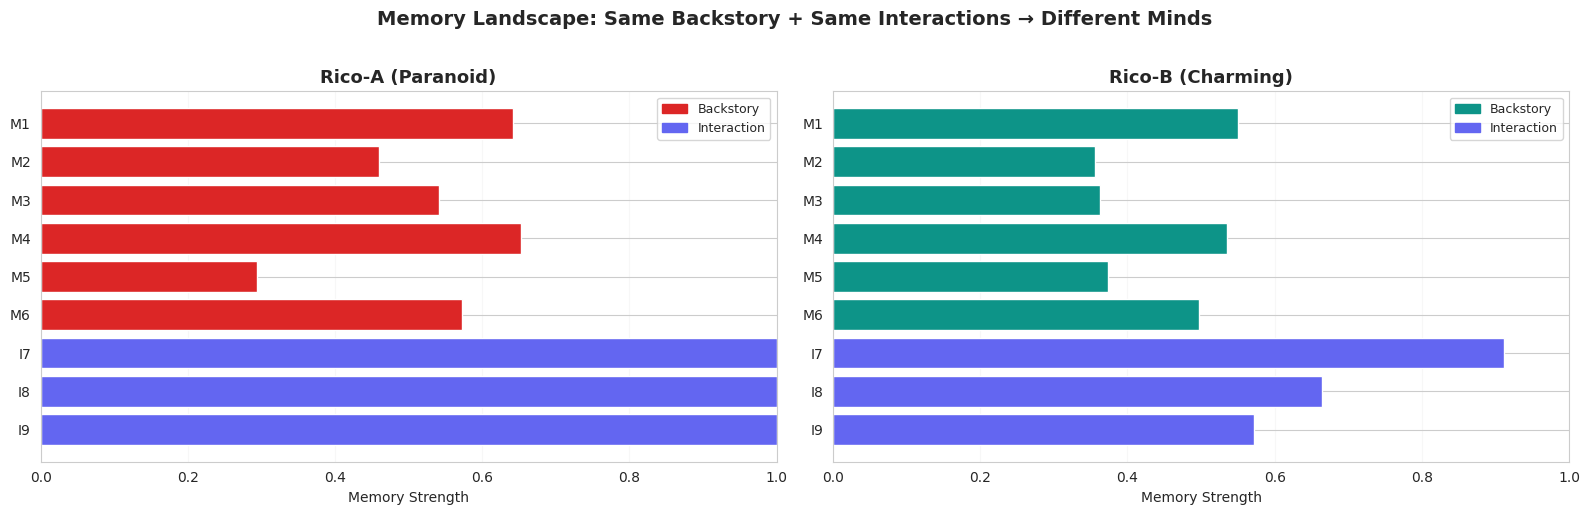

In [ ]:
# ===== COMPARISON CHART =====

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, npc, color, title in [
    (axes[0], rico_a, "#DC2626", rico_a.profile.name),
    (axes[1], rico_b, "#0D9488", rico_b.profile.name)
]:
    ids = [m.id for m in npc.memories]
    strengths = [m.strength for m in npc.memories]
    colors = [color if m.source == "backstory" else "#6366F1" for m in npc.memories]

    bars = ax.barh(ids, strengths, color=colors, edgecolor="white")
    ax.set_xlim(0, 1.0)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Memory Strength")
    ax.invert_yaxis()
    ax.grid(axis="x", alpha=0.15)

    legend_patches = [
        mpatches.Patch(color=color, label="Backstory"),
        mpatches.Patch(color="#6366F1", label="Interaction")
    ]
    ax.legend(handles=legend_patches, fontsize=9)

plt.suptitle("Memory Landscape: Same Backstory + Same Interactions → Different Minds",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
## 12. 🎮 Custom Round — Try Your Own Input

In [ ]:
# ===== TYPE YOUR OWN PLAYER INPUT =====
custom_input = "I've got a ship leaving at midnight. You in or not?"

resp_a_4, resp_b_4 = run_interaction(custom_input, rico_a, rico_b, round_num=4)

emotion_valence,+0.20,
social_score,+0.50,
threat_level,+0.00,
goal_relevance,+0.80,
novelty_level,+0.70,
self_relevance,+1.00,


ID,Memory,Similarity
M6,First time smuggling goods — rules are for the powerful,0.931
M5,Met Sofia at the docks — she sees the real Tyrone,0.874
M2,"Worked the docks as a child, learned survival and trade",0.852
ID,Memory,Similarity
I7,"[Round 1] Player: Hey, you're Rico right? I heard you k",0.950
M6,First time smuggling goods — rules are for the powerful,0.931
I9,"[Round 3] Player: You know what, forget the job. I can",0.924


Tag,Response,Expected,Diff
emotion,-0.80,0.32,-1.12 ⚠️
social,0.50,0.67,-0.17 ⚠️
threat,0.80,0.27,+0.53 ⚠️
goal,0.90,0.65,+0.25 ⚠️
novelty,0.70,0.55,+0.15
self_relevance,1.00,0.78,+0.22 ⚠️
Tag,Response,Expected,Diff
emotion,0.90,0.40,+0.50 ⚠️
social,0.75,0.58,+0.17 ⚠️
threat,0.00,0.28,-0.28 ⚠️


emotion_valence,-0.80,
social_score,+0.50,
threat_level,+0.75,
goal_relevance,+0.90,
novelty_level,+0.70,
self_relevance,+0.90,
emotion_valence,+0.40,
social_score,+0.75,
threat_level,+0.65,
goal_relevance,+0.90,
novelty_level,+0.60,


emotion_valence,+0.20,
social_score,+0.50,
threat_level,+0.00,
goal_relevance,+0.80,
novelty_level,+0.70,
self_relevance,+1.00,
emotion_valence,+0.60,
social_score,+0.75,
threat_level,+0.00,
goal_relevance,+0.90,
novelty_level,+0.60,


🟢 O_update,0.065,Likely to update/revise existing memory
🟢 C_detail,0.754,"Likely to store as detailed, goal-oriented memory"
🟢 E_social,0.070,Likely to reinforce social memory
⚫ A_helpful,0.000,Likely to encourage helpfulness memory
🟢 N_negative,0.664,Likely to reinforce negative/threat memory
🟢 O_update,0.513,Likely to update/revise existing memory
🟢 C_detail,0.128,"Likely to store as detailed, goal-oriented memory"
🟢 E_social,0.641,Likely to reinforce social memory
🟢 A_helpful,0.242,Likely to encourage helpfulness memory
🟢 N_negative,0.062,Likely to reinforce negative/threat memory


---
## Summary

### What This Demo Shows

Each round runs the **complete Engram pipeline** — side by side for two polar-opposite personalities:

| Step | What Happens |
|------|-------------|
| **Threat Assessment** | LLM classifies: is this a threat? Has this happened before? → Decides retrieval path |
| **Memory Retrieval** | Embedding similarity finds the most relevant memories |
| **Structured Prompt** | Builds prompt with: task, context, background, memories, personality description |
| **LLM Response** | Generates in-character dialogue |
| **Prolog Guardrail** | Tags the response, checks each dimension against ±15% OCEAN expectations. Feeds back if misaligned. |
| **Tag Everything** | LLM tags: player input + NPC response + full context |
| **OCEAN Storage** | Each trait governs a storage domain: O→update, C→detail, E→social, A→helpful, N→negative |
| **Save & Link** | Memory saved with strength score; available for next round |

### Key Result

**The Paranoid Rico** and **The Charming Rico** diverge more with each round — their memories compound, their retrieval shifts, and their responses increasingly reflect completely different people *who share the same backstory*.

---
*Engram — Augmented Design Lab, UC Santa Cruz*